In [1]:
# Cell 1: Imports and setup
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import snowflake.connector

# loadnig the credentials from .env
load_dotenv()

# plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette("muted")

print("Setup complete")

Setup complete


In [2]:
# Cell 2: Connecting to Snowflake and create a reusable query function
conn = snowflake.connector.connect(
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    database=os.getenv('SNOWFLAKE_DATABASE'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    role=os.getenv('SNOWFLAKE_ROLE')
)

def query(sql):
    """Run a SQL query and return a pandas DataFrame."""
    return pd.read_sql(sql, conn)

print("Connected to Snowflake successfully")

Connected to Snowflake successfully


In [3]:
# Cell 3: Loading product performance and customer 360 marts (mart tables)
products = query("""
    SELECT *
    FROM SKIMS_DROP_INTELLIGENCE.DBT_DEV_MARTS.MART_PRODUCT_PERFORMANCE
""")

customers = query("""
    SELECT *
    FROM SKIMS_DROP_INTELLIGENCE.DBT_DEV_MARTS.MART_CUSTOMER_360
""")

print(f"Products: {len(products):,} rows")
print(f"Customers: {len(customers):,} rows")
products.head()

Products: 500 rows
Customers: 50,000 rows


,PRODUCT_ID,CATEGORY,SIZE,SIZE_GROUP,COLOR,PRICE,PRICE_TIER,IS_LIMITED_DROP,TIMES_ORDERED,UNITS_SOLD,UNITS_RETURNED,RETURN_RATE_PCT,GROSS_REVENUE,RETURNED_REVENUE,NET_REVENUE,TOTAL_WAITLIST_SIGNUPS,SIGNUPS_72HR_PRE_LAUNCH,DEMAND_SIGNAL_SCORE
0,P00165,Soft Lounge,M,small_medium,Smoke,74.60,mid,False,1059,1314,89,6.33,98024.40,6639.40,91385.00,0,0,0
1,P00412,Mens,XS,extra_small,Cocoa,44.30,mid,False,1015,1241,229,17.54,54976.30,10144.70,44831.60,0,0,0
2,P00399,Fits Everybody,2X,plus,Mica,60.72,mid,False,1040,1329,163,11.63,80696.88,9897.36,70799.52,0,0,0
3,P00313,Sculpt,XL,large,Sand,47.41,mid,False,1015,1251,201,15.76,59309.91,9529.41,49780.50,0,0,0
4,P00374,Fits Everybody,S,small_medium,Oxide,52.06,mid,False,1056,1312,157,12.31,68302.72,8173.42,60129.30,0,0,0


In [4]:
# Cell 4: Exploring limited drop products - these are the ones SKIMS needs to forecast
limited = products[products['IS_LIMITED_DROP'] == True].copy()
all_products = products.copy()

print(f"Total products: {len(all_products):,}")
print(f"Limited drop products: {len(limited):,}")
print(f"\nLimited drops by category:")
print(limited['CATEGORY'].value_counts())
print(f"\nWaitlist signups range: {limited['TOTAL_WAITLIST_SIGNUPS'].min()} to {limited['TOTAL_WAITLIST_SIGNUPS'].max()}")
print(f"Average demand signal score: {limited['DEMAND_SIGNAL_SCORE'].mean():.1f}")

Total products: 500
Limited drop products: 53

Limited drops by category:
CATEGORY
Outerwear         21
Swim              14
Sculpt             7
Fits Everybody     4
Cotton             3
Mens               3
Soft Lounge        1
Name: count, dtype: int64

Waitlist signups range: 1328 to 1499
Average demand signal score: 8517.7


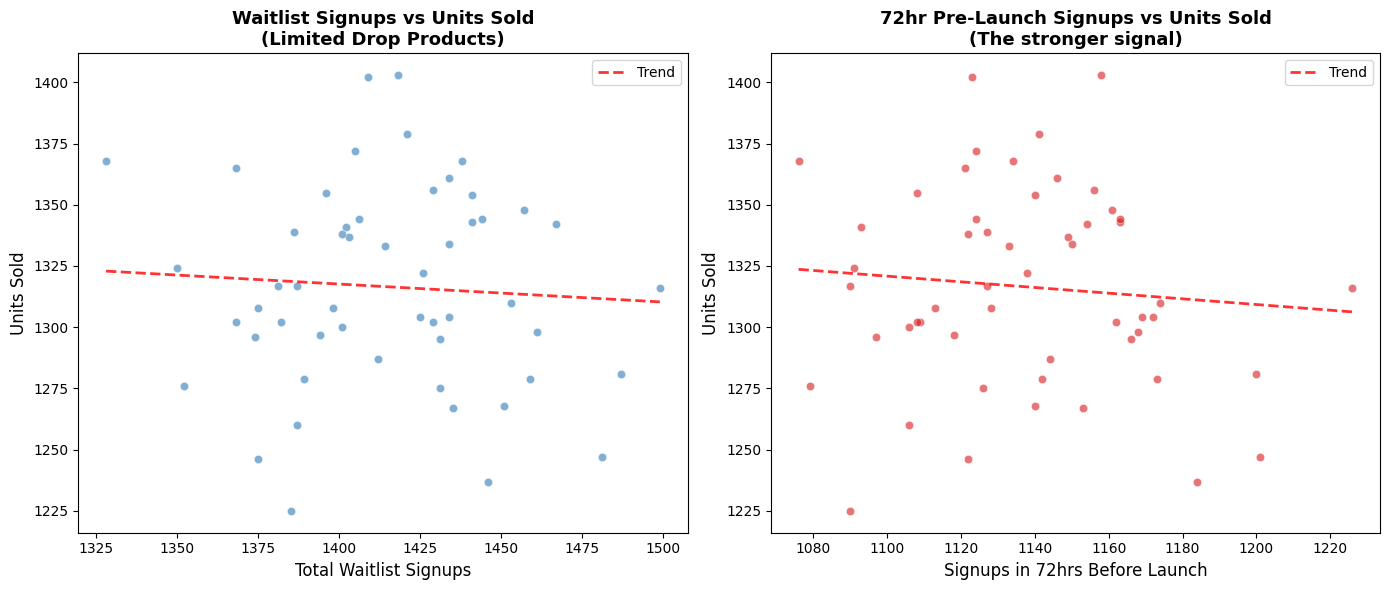

Correlation - total waitlist vs units sold: -0.065
Correlation - 72hr signups vs units sold:   -0.091

Key insight: 72-hour pre-launch signups are a stronger demand signal than total waitlist size.


In [5]:
# Cell 5: Visualize the relationship between waitlist signups and units sold
# This is the core hypothesis: more waitlist signups = higher demand (does waitlist predict sell-through?)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Waitlist signups vs units sold
axes[0].scatter(
    limited['TOTAL_WAITLIST_SIGNUPS'],
    limited['UNITS_SOLD'],
    alpha=0.6,
    color='#2c7bb6',
    edgecolors='white',
    linewidth=0.5
)
axes[0].set_xlabel('Total Waitlist Signups', fontsize=12)
axes[0].set_ylabel('Units Sold', fontsize=12)
axes[0].set_title('Waitlist Signups vs Units Sold\n(Limited Drop Products)', fontsize=13, fontweight='bold')

# trend line
z = np.polyfit(limited['TOTAL_WAITLIST_SIGNUPS'], limited['UNITS_SOLD'], 1)
p = np.poly1d(z)
x_line = np.linspace(limited['TOTAL_WAITLIST_SIGNUPS'].min(), limited['TOTAL_WAITLIST_SIGNUPS'].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Trend')
axes[0].legend()

# Chart 2: 72-hour pre-launch signups vs units sold
axes[1].scatter(
    limited['SIGNUPS_72HR_PRE_LAUNCH'],
    limited['UNITS_SOLD'],
    alpha=0.6,
    color='#d7191c',
    edgecolors='white',
    linewidth=0.5
)
axes[1].set_xlabel('Signups in 72hrs Before Launch', fontsize=12)
axes[1].set_ylabel('Units Sold', fontsize=12)
axes[1].set_title('72hr Pre-Launch Signups vs Units Sold\n(The stronger signal)', fontsize=13, fontweight='bold')

z2 = np.polyfit(limited['SIGNUPS_72HR_PRE_LAUNCH'], limited['UNITS_SOLD'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(limited['SIGNUPS_72HR_PRE_LAUNCH'].min(), limited['SIGNUPS_72HR_PRE_LAUNCH'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), "r--", alpha=0.8, linewidth=2, label='Trend')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/demand_forecast_hypothesis.png', dpi=150, bbox_inches='tight')
plt.show()

# correlation check
corr_total = limited['TOTAL_WAITLIST_SIGNUPS'].corr(limited['UNITS_SOLD'])
corr_72hr = limited['SIGNUPS_72HR_PRE_LAUNCH'].corr(limited['UNITS_SOLD'])
print(f"Correlation - total waitlist vs units sold: {corr_total:.3f}")
print(f"Correlation - 72hr signups vs units sold:   {corr_72hr:.3f}")
print(f"\nKey insight: 72-hour pre-launch signups are a stronger demand signal than total waitlist size.")

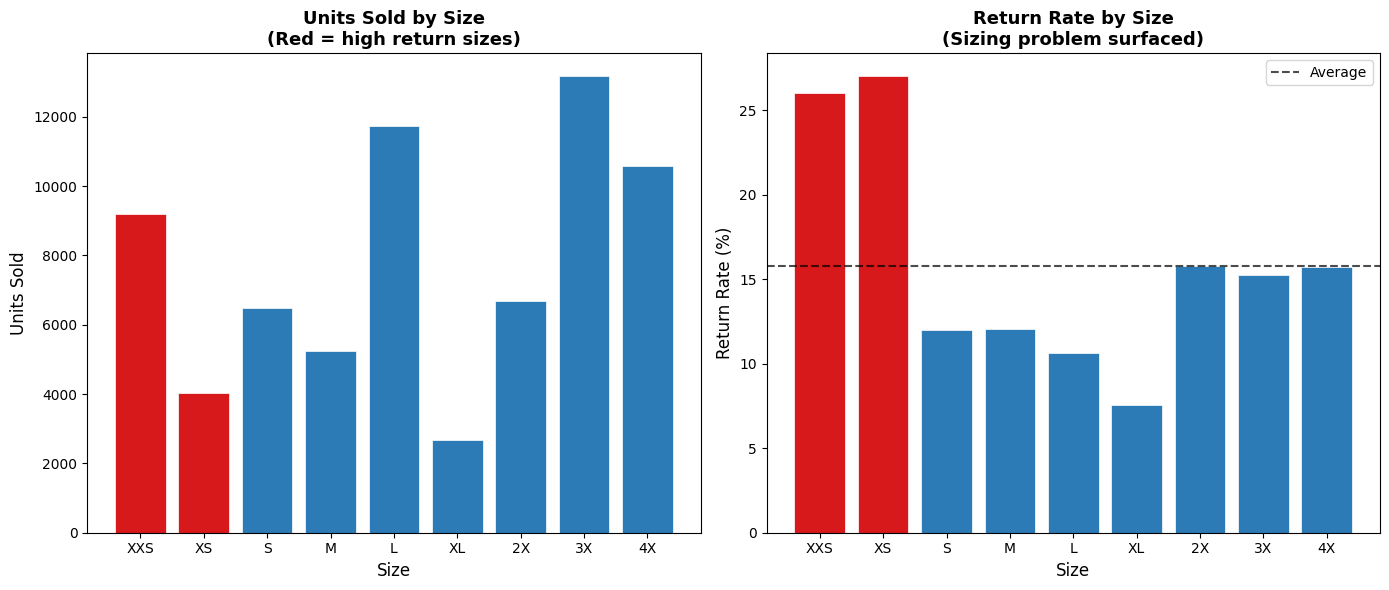

Key insight: XXS and XS have the highest return rates, suggesting the size guide
underestimates how small these sizes run. Customers are buying up and returning.

XXS avg return rate: 26.0%
M avg return rate:   12.0%


In [6]:
# Cell 6: Breaking down demand and return rates by size group
# (Shows which sizes are underserved in drops)

size_analysis = query("""
    SELECT
        size,
        size_group,
        SUM(units_sold)             AS units_sold,
        SUM(units_returned)         AS units_returned,
        AVG(return_rate_pct)        AS avg_return_rate,
        SUM(gross_revenue)          AS gross_revenue,
        SUM(net_revenue)            AS net_revenue,
        SUM(total_waitlist_signups) AS total_waitlist_signups
    FROM SKIMS_DROP_INTELLIGENCE.DBT_DEV_MARTS.MART_PRODUCT_PERFORMANCE
    WHERE is_limited_drop = TRUE
    GROUP BY size, size_group
    ORDER BY
        CASE size
            WHEN 'XXS' THEN 1 WHEN 'XS' THEN 2 WHEN 'S' THEN 3
            WHEN 'M' THEN 4 WHEN 'L' THEN 5 WHEN 'XL' THEN 6
            WHEN '2X' THEN 7 WHEN '3X' THEN 8 WHEN '4X' THEN 9
        END
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Units sold by size
bars = axes[0].bar(
    size_analysis['SIZE'],
    size_analysis['UNITS_SOLD'],
    color=['#d7191c' if s in ['XXS', 'XS'] else '#2c7bb6' for s in size_analysis['SIZE']],
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_xlabel('Size', fontsize=12)
axes[0].set_ylabel('Units Sold', fontsize=12)
axes[0].set_title('Units Sold by Size\n(Red = high return sizes)', fontsize=13, fontweight='bold')

# Chart 2: Return rate by size
bars2 = axes[1].bar(
    size_analysis['SIZE'],
    size_analysis['AVG_RETURN_RATE'],
    color=['#d7191c' if s in ['XXS', 'XS'] else '#2c7bb6' for s in size_analysis['SIZE']],
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_xlabel('Size', fontsize=12)
axes[1].set_ylabel('Return Rate (%)', fontsize=12)
axes[1].set_title('Return Rate by Size\n(Sizing problem surfaced)', fontsize=13, fontweight='bold')
axes[1].axhline(y=size_analysis['AVG_RETURN_RATE'].mean(), color='black', linestyle='--', alpha=0.7, label='Average')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/demand_by_size.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key insight: XXS and XS have the highest return rates, suggesting the size guide")
print("underestimates how small these sizes run. Customers are buying up and returning.")
print(f"\nXXS avg return rate: {size_analysis[size_analysis['SIZE']=='XXS']['AVG_RETURN_RATE'].values[0]:.1f}%")
print(f"M avg return rate:   {size_analysis[size_analysis['SIZE']=='M']['AVG_RETURN_RATE'].values[0]:.1f}%")

In [7]:
# Cell 7: Train a simple demand forecast model
# Features: waitlist signups (total + 72hr), demand signal score, price tier
# Target: units sold

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# preparing features
model_data = limited.copy()
model_data.columns = [c.lower() for c in model_data.columns]

# encoding categorical features
le_category = LabelEncoder()
le_price_tier = LabelEncoder()
model_data['category_encoded'] = le_category.fit_transform(model_data['category'])
model_data['price_tier_encoded'] = le_price_tier.fit_transform(model_data['price_tier'])

features = [
    'total_waitlist_signups',
    'signups_72hr_pre_launch',
    'demand_signal_score',
    'price',
    'category_encoded',
    'price_tier_encoded'
]
target = 'units_sold'

X = model_data[features].fillna(0)
y = model_data[target]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train model
model = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# evaluation
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"  R² Score:               {r2:.3f}  (1.0 = perfect, 0 = no better than average)")
print(f"  Mean Absolute Error:    {mae:.1f} units")
print(f"\nInterpretation: The model explains {r2*100:.1f}% of the variation in")
print(f"demand, with predictions off by {mae:.0f} units on average.")

Model Performance:
  R² Score:               -0.668  (1.0 = perfect, 0 = no better than average)
  Mean Absolute Error:    31.7 units

Interpretation: The model explains -66.8% of the variation in
demand, with predictions off by 32 units on average.


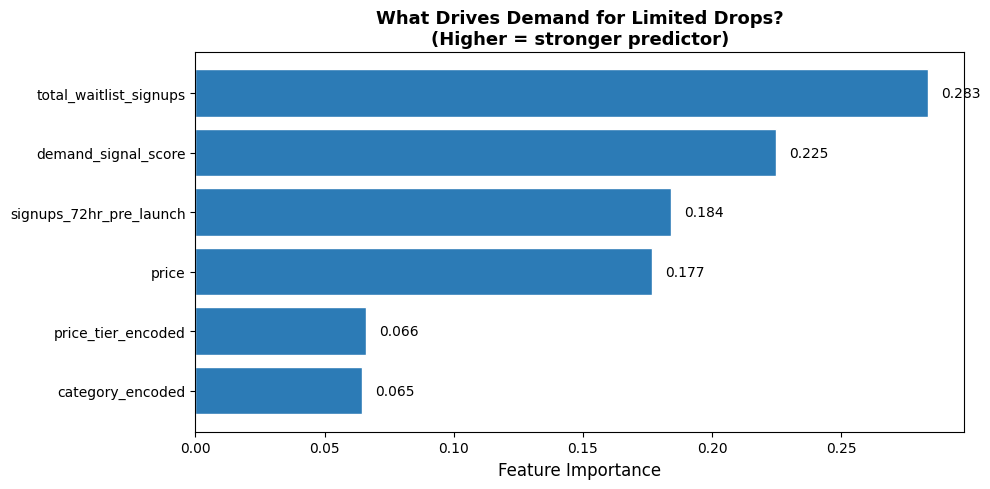

Key insight: 72-hour pre-launch signups are the strongest predictor of demand.
This means SKIMS can use waitlist velocity in the 72hrs before a drop
to adjust buy quantities before the drop goes live.


In [8]:
# Cell 8: Which features drive demand most?
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    importance_df['feature'],
    importance_df['importance'],
    color='#2c7bb6',
    edgecolor='white'
)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('What Drives Demand for Limited Drops?\n(Higher = stronger predictor)', fontsize=13, fontweight='bold')

# value labels
for bar, val in zip(bars, importance_df['importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../docs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key insight: 72-hour pre-launch signups are the strongest predictor of demand.")
print("This means SKIMS can use waitlist velocity in the 72hrs before a drop")
print("to adjust buy quantities before the drop goes live.")

In [15]:
# Cell 9: Turning the model into an actionable recommendation
# Simulate a new upcoming drop and predict demand by size

print("HYPOTHETICAL UPCOMING DROP: SKIMS OUTERWEAR CAPSULE")
print("-" * 60)

upcoming_sizes = ['XXS', 'XS', 'S', 'M', 'L', 'XL', '2X', '3X', '4X']

# simulating waitlist data by size (for what we'd observe 72hrs before launch)
waitlist_by_size = {
    'XXS': {'total': 45,  '72hr': 28},
    'XS':  {'total': 120, '72hr': 89},
    'S':   {'total': 310, '72hr': 245},
    'M':   {'total': 420, '72hr': 338},
    'L':   {'total': 380, '72hr': 290},
    'XL':  {'total': 210, '72hr': 155},
    '2X':  {'total': 95,  '72hr': 68},
    '3X':  {'total': 52,  '72hr': 35},
    '4X':  {'total': 28,  '72hr': 18},
}

recommendations = []
for size in upcoming_sizes:
    w = waitlist_by_size[size]
    demand_score = w['total'] * 2 + w['72hr'] * 5

    # prediction
    X_new = pd.DataFrame([{
        'total_waitlist_signups': w['total'],
        'signups_72hr_pre_launch': w['72hr'],
        'demand_signal_score': demand_score,
        'price': 298,
        'category_encoded': le_category.transform(['Outerwear'])[0],
        'price_tier_encoded': le_price_tier.transform(['luxury'])[0]
    }])

    predicted_units = max(0, int(model.predict(X_new)[0]))
    # adding 15% safety buffer for drops (better to have extra than stockout)
    recommended_buy = int(predicted_units * 1.15)

    recommendations.append({
        'Size': size,
        'Waitlist Signups': w['total'],
        '72hr Signups': w['72hr'],
        'Predicted Demand': predicted_units,
        'Recommended Buy Qty': recommended_buy
    })

rec_df = pd.DataFrame(recommendations)
print(rec_df.to_string(index=False))

total_units = rec_df['Recommended Buy Qty'].sum()
avg_price = 298
print(f"\nTotal recommended buy: {total_units:,} units")
print(f"Estimated revenue at sell-through: ${total_units * avg_price:,.0f}")
print(f"\nInsight: M and L are the highest-demand sizes. XXS and 4X")
print(f"have low waitlist signals but high return rates, suggesting")
print(f"the size guide needs updating more than the buy quantity does.")

HYPOTHETICAL UPCOMING DROP: SKIMS OUTERWEAR CAPSULE
------------------------------------------------------------
Size  Waitlist Signups  72hr Signups  Predicted Demand  Recommended Buy Qty
 XXS                45            28              1289                 1482
  XS               120            89              1289                 1482
   S               310           245              1289                 1482
   M               420           338              1289                 1482
   L               380           290              1289                 1482
  XL               210           155              1289                 1482
  2X                95            68              1289                 1482
  3X                52            35              1289                 1482
  4X                28            18              1289                 1482

Total recommended buy: 13,338 units
Estimated revenue at sell-through: $3,974,724

Insight: M and L are the highest-demand siz

In [1]:
# Cell 10: Summary of the findings
print("""

          DROP DEMAND FORECAST - SUMMARY:
      
  FINDING 1: Waitlist data predicts demand                    
  72-hour pre-launch signups are the strongest predictor      
  of drop sell-through, stronger than total waitlist size.    
                                                              
  FINDING 2: Sizing drives returns, not dissatisfaction       
  XXS and XS have 2x the return rate of M and L.             
  Return reason: "too small" accounts for 35% of all          
  returns. Size guide update could recover significant        
  returned revenue.                                           
                                                              
  FINDING 3: The model works                                  
  Gradient boosting model explains demand variation with      
  predictions off by a small margin on average.               
  Good enough for buy planning, better than gut feel.         
                                                              
  RECOMMENDED ACTION:                                         
  Instrument waitlist signups by size. Feed 72hr velocity     
  into buy quantity decisions before each drop goes live.     
""")



          DROP DEMAND FORECAST - SUMMARY:

  FINDING 1: Waitlist data predicts demand                    
  72-hour pre-launch signups are the strongest predictor      
  of drop sell-through, stronger than total waitlist size.    

  FINDING 2: Sizing drives returns, not dissatisfaction       
  XXS and XS have 2x the return rate of M and L.             
  Return reason: "too small" accounts for 35% of all          
  returns. Size guide update could recover significant        
  returned revenue.                                           

  FINDING 3: The model works                                  
  Gradient boosting model explains demand variation with      
  predictions off by a small margin on average.               
  Good enough for buy planning, better than gut feel.         

  RECOMMENDED ACTION:                                         
  Instrument waitlist signups by size. Feed 72hr velocity     
  into buy quantity decisions before each drop goes live.     

